# Comment stat visualizations

In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import importlib

#importing the streaming data
CWD = os.getcwd()
comment_dir = "cleaned_comments"
comment_file = "cleaned_comments.csv"
song_stat_path = os.path.join(CWD, comment_dir, comment_file)

#getting data
headernames = ["comment_id", 'text', 'date', 'song', 'artist', 'kendrick_score', 'drake_score']
comment_stats = pd.read_csv(filepath_or_buffer=song_stat_path, header=0, names=headernames)

In [2]:
#quick sanity check on what values are actually in these columns before filtering on them
comment_stats['date'] = pd.to_datetime(comment_stats['date'])

print(comment_stats['song'].unique())
print(comment_stats['artist'].unique())
comment_stats

['Family_Matters' 'First_Person_Shooter' 'Like_That' 'Push_Ups' 'Euphoria'
 '616_in_LA' 'Meet_the_Grahams' 'Not_Like_Us' 'The_Heart_Part_6']
['BagOnly_Drake' 'Drake' 'Future' 'ScruFaceJean_Drake' 'Kendrick_Lamar'
 'RapNation_Kendrick_Lamar']


,comment_id,text,date,song,artist,kendrick_score,drake_score
0,Ugzc5Srhx8p6qzdSjvB4AaABAg,Kendrick responded so fast I didnt know Drake ...,2024-05-04 12:59:37+00:00,Family_Matters,BagOnly_Drake,2,-1
1,UgxGl-mJYHo4mzjNy0R4AaABAg,Beat switches each time a different ghost writ...,2024-05-04 08:41:23+00:00,Family_Matters,BagOnly_Drake,0,-2
2,Ugw8sI-rRjgKXTUCBFV4AaABAg,Kendrick had a diss ready for this song not ev...,2024-05-04 05:18:35+00:00,Family_Matters,BagOnly_Drake,2,0
3,UgzkG6vRyh2O9FOlnJR4AaABAg,Imagine sitting down in a group and writing th...,2024-05-04 17:04:41+00:00,Family_Matters,BagOnly_Drake,1,-1
4,UgyRU5sH2RugrPSNal94AaABAg,ngl Drake's melody is fire\n\nbut Kendrick's l...,2024-05-05 06:28:06+00:00,Family_Matters,BagOnly_Drake,3,2
...,...,...,...,...,...,...,...
3094,Ugy431xHLl8kF58wTkp4AaABAg,1:38💀💀💀.Mother I-,2024-05-23 23:10:48+00:00,The_Heart_Part_6,Drake,0,1
3095,UgzaRNJ6h5bP24jGTuF4AaABAg,If u truly planted the misinformation about ur...,2024-05-06 09:44:19+00:00,The_Heart_Part_6,Drake,0,-3
3096,UgyMSxOWLZ7VVk-UO1F4AaABAg,I feel like somebody is gonna get shot at this...,2024-05-06 01:28:07+00:00,The_Heart_Part_6,Drake,-1,-1
3097,UgzkvuGmdVoKNZJlW7h4AaABAg,Who’s here after the music video 😭,2024-07-05 00:16:37+00:00,The_Heart_Part_6,Drake,1,0


### plotting the histogram of comment scores at the beginning of the beef vs end for each artist

fps: mean: 0.6324435318275154, std:1.7498649946147493, var: 3.0620274993780767
the heart part 6: mean: -0.6159695817490495, std:1.9753354893922896, var: 3.9019502956526764


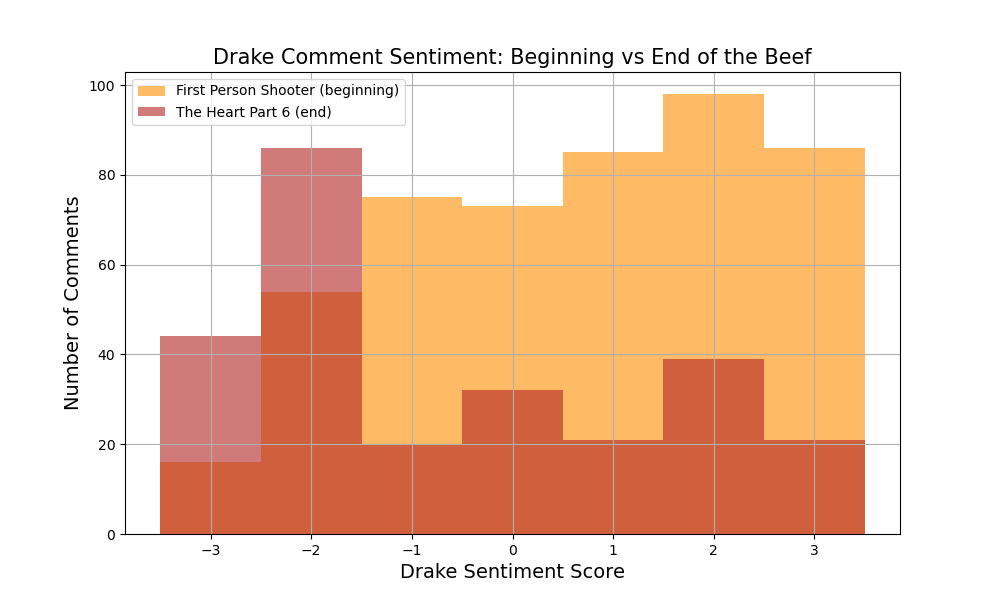

In [5]:
#drake histogram for comment scores from First Person Shooter and from the Heart Part 6
%matplotlib widget

title_fontsize = 15
axis_label_fontsize = 14
axes_fontsize = 13

plt.close('all')
plt.figure(figsize=(10, 6))

#grabbing the data
fps_scores = comment_stats.loc[comment_stats['song'] == 'First_Person_Shooter', 'drake_score'].dropna()
heart6_scores = comment_stats.loc[comment_stats['song'] == 'The_Heart_Part_6', 'drake_score'].dropna()

#plotting
bins = np.arange(-3.5, 4.5, 1)

plt.hist(fps_scores, bins=bins, alpha=0.6, label='First Person Shooter (beginning)', color='darkorange')
plt.hist(heart6_scores, bins=bins, alpha=0.6, label='The Heart Part 6 (end)', color='firebrick')

#stats
print(f"fps: mean: {np.mean(fps_scores)}, std:{np.std(fps_scores)}, var: {np.var(fps_scores)}")
print(f"the heart part 6: mean: {np.mean(heart6_scores)}, std:{np.std(heart6_scores)}, var: {np.var(heart6_scores)}")

plt.title("Drake Comment Sentiment: Beginning vs End of the Beef", fontsize=title_fontsize)
plt.xlabel("Drake Sentiment Score", fontsize=axis_label_fontsize)
plt.ylabel("Number of Comments", fontsize=axis_label_fontsize)
plt.rcParams['axes.labelsize'] = axes_fontsize
plt.legend(loc='best', fontsize=10)
plt.grid(True)
plt.show()

Like that: mean: 1.6448979591836734, std:1.0692475371541055, var: 1.1432902957101203
Not Like Us: mean: 2.0830188679245283, std:0.6148280474619621, var: 0.3780135279458887


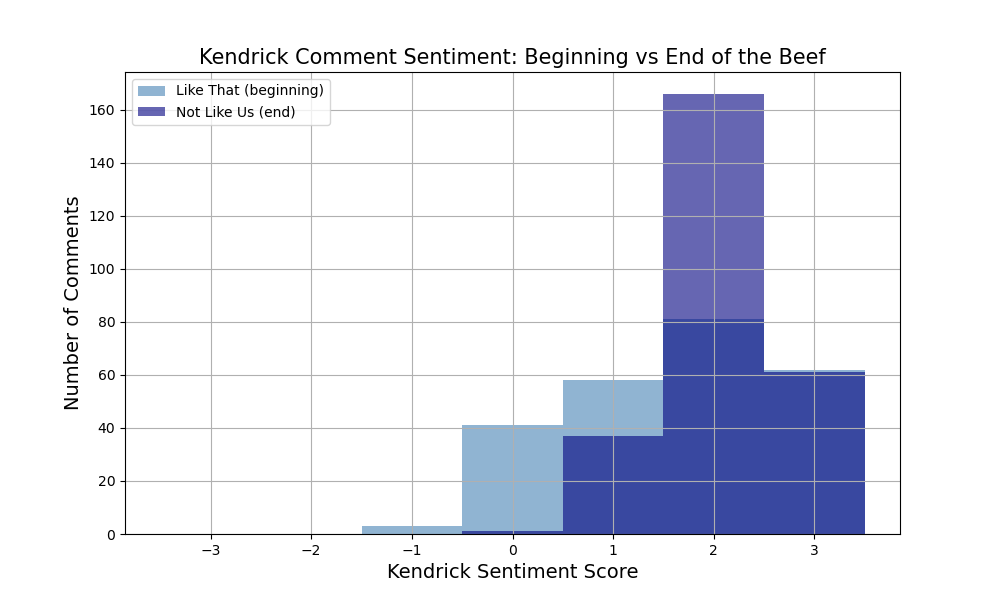

In [8]:
#Kdot histogram for comment scores from Like That and from Not Like Us
plt.close('all')
plt.figure(figsize=(10, 6))

#pulling data
like_that_scores = comment_stats.loc[comment_stats['song'] == 'Like_That', 'kendrick_score'].dropna()
nlu_scores = comment_stats.loc[comment_stats['song'] == 'Not_Like_Us', 'kendrick_score'].dropna()

#plotting
plt.hist(like_that_scores, bins=bins, alpha=0.6, label='Like That (beginning)', color='steelblue')
plt.hist(nlu_scores, bins=bins, alpha=0.6, label='Not Like Us (end)', color='navy')

#stats
print(f"Like that: mean: {np.mean(like_that_scores)}, std:{np.std(like_that_scores)}, var: {np.var(like_that_scores)}")
print(f"Not Like Us: mean: {np.mean(nlu_scores)}, std:{np.std(nlu_scores)}, var: {np.var(nlu_scores)}")

plt.title("Kendrick Comment Sentiment: Beginning vs End of the Beef", fontsize=title_fontsize)
plt.xlabel("Kendrick Sentiment Score", fontsize=axis_label_fontsize)
plt.ylabel("Number of Comments", fontsize=axis_label_fontsize)
plt.rcParams['axes.labelsize'] = axes_fontsize
plt.legend(loc='best', fontsize=10)
plt.grid(True)
plt.show()

### plotting the j cole mentions over time

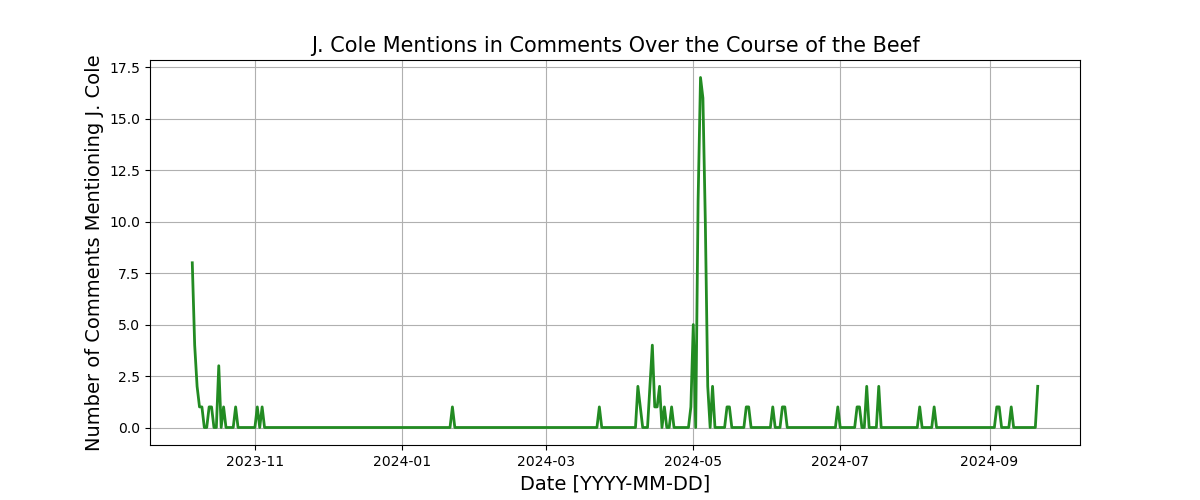

In [7]:
#pulling j cole mentions and the dates they happen at
j_cole_pattern = r'\bj\.?\s*cole\b|\bjcole\b'
comment_stats['mentions_j_cole'] = comment_stats['text'].str.contains(j_cole_pattern, case=False, regex=True, na=False)

comment_stats['date'] = pd.to_datetime(comment_stats['date'], errors='coerce')
# j_cole_by_date = comment_stats.loc[comment_stats['mentions_j_cole']].groupby('date').size()
j_cole_by_date = comment_stats.loc[comment_stats['mentions_j_cole']].copy()

#binning into one hour intervals
j_cole_by_hr = (j_cole_by_date.set_index('date').resample('d').size())


plt.close('all')
plt.figure(figsize=(12, 5))

plt.plot(j_cole_by_hr.index, j_cole_by_hr.values, color='forestgreen', lw=2)

plt.title("J. Cole Mentions in Comments Over the Course of the Beef", fontsize=title_fontsize)
plt.xlabel("Date [YYYY-MM-DD]", fontsize=axis_label_fontsize)
plt.ylabel("Number of Comments Mentioning J. Cole", fontsize=axis_label_fontsize)
plt.rcParams['axes.labelsize'] = axes_fontsize
plt.grid(True)
plt.show()

### Plotting the comment sentiment for Drake from a neutral source (BagOnly) vs his own channel for the song Family Matters 

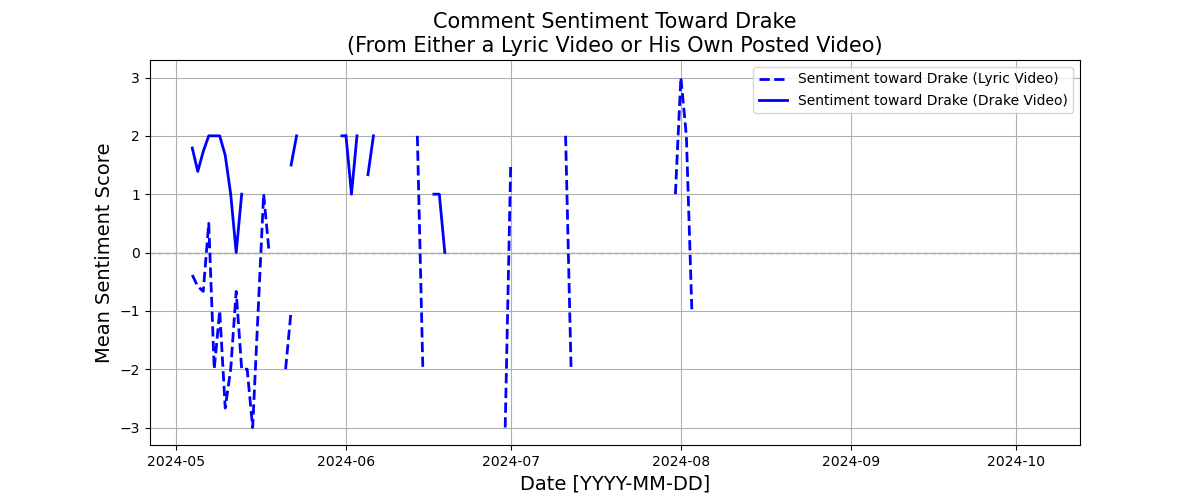

In [14]:
plt.close('all')
plt.figure(figsize=(12, 5))

fm_song_comments = comment_stats.loc[comment_stats['song'].isin(['Family_Matters'])]

drake_song_comments = fm_song_comments.loc[fm_song_comments['artist'].isin(['Drake'])]
bagonly_song_comments = fm_song_comments.loc[fm_song_comments['artist'].isin(["BagOnly_Drake"])]

daily_bagonly_drake = bagonly_song_comments.set_index('date').resample('D')['drake_score'].mean()
daily_drake_drake = drake_song_comments.set_index('date').resample('D')['drake_score'].mean()

plt.plot(daily_bagonly_drake.index, daily_bagonly_drake.values, label='Sentiment toward Drake (Lyric Video)', color='blue', lw=2, ls='--')
plt.plot(daily_drake_drake.index, daily_drake_drake.values, label='Sentiment toward Drake (Drake Video)', color='blue', lw=2)

plt.axhline(y=0, color='gray', lw=1, ls='--', zorder=0)

plt.title("Comment Sentiment Toward Drake\n(From Either a Lyric Video or His Own Posted Video)", fontsize=title_fontsize)
plt.xlabel("Date [YYYY-MM-DD]", fontsize=axis_label_fontsize)
plt.ylabel("Mean Sentiment Score", fontsize=axis_label_fontsize)
plt.rcParams['axes.labelsize'] = axes_fontsize
plt.legend(loc='best', fontsize=10)
plt.grid(True)
plt.show()

### plotting the comment sentiment for Drake for a react channel video vs one of his songs from a similar release date in the beef

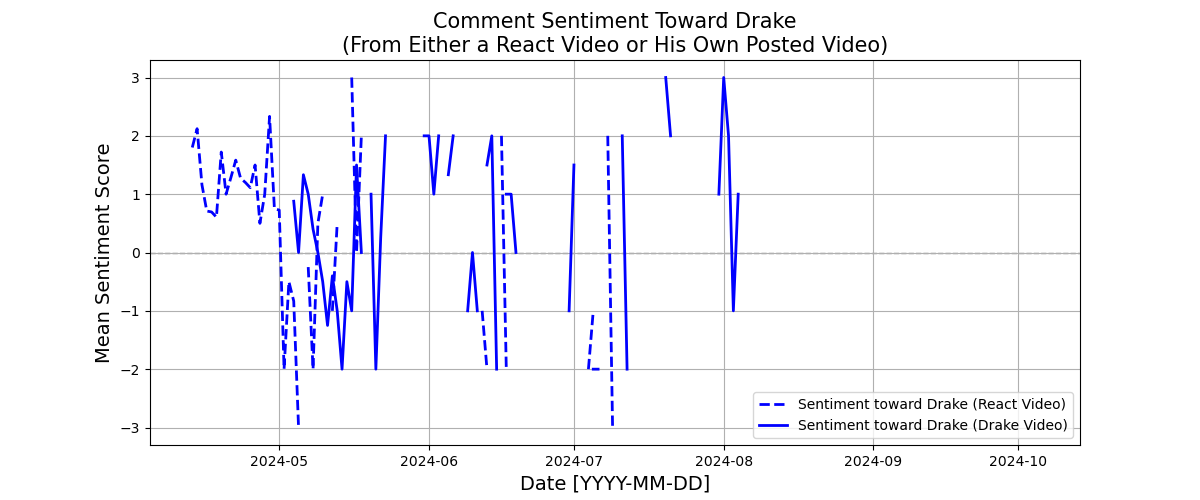

In [13]:
plt.close('all')
plt.figure(figsize=(12, 5))

scru_song_comments = comment_stats.loc[comment_stats['song'].isin(['Push_Ups'])]
drake_song_comments = comment_stats.loc[comment_stats['song'].isin(['Family_Matters'])]

daily_drake_scru = scru_song_comments.set_index('date').resample('D')['drake_score'].mean()
daily_drake_drake = drake_song_comments.set_index('date').resample('D')['drake_score'].mean()

plt.plot(daily_drake_scru.index, daily_drake_scru.values, label='Sentiment toward Drake (React Video)', color='blue', lw=2, ls='--')
plt.plot(daily_drake_drake.index, daily_drake_drake.values, label='Sentiment toward Drake (Drake Video)', color='blue', lw=2)

plt.axhline(y=0, color='gray', lw=1, ls='--', zorder=0)

plt.title("Comment Sentiment Toward Drake\n(From Either a React Video or His Own Posted Video)", fontsize=title_fontsize)
plt.xlabel("Date [YYYY-MM-DD]", fontsize=axis_label_fontsize)
plt.ylabel("Mean Sentiment Score", fontsize=axis_label_fontsize)
plt.rcParams['axes.labelsize'] = axes_fontsize
plt.legend(loc='best', fontsize=10)
plt.grid(True)
plt.show()

### plotting the comment sentiment for both artists from drake songs

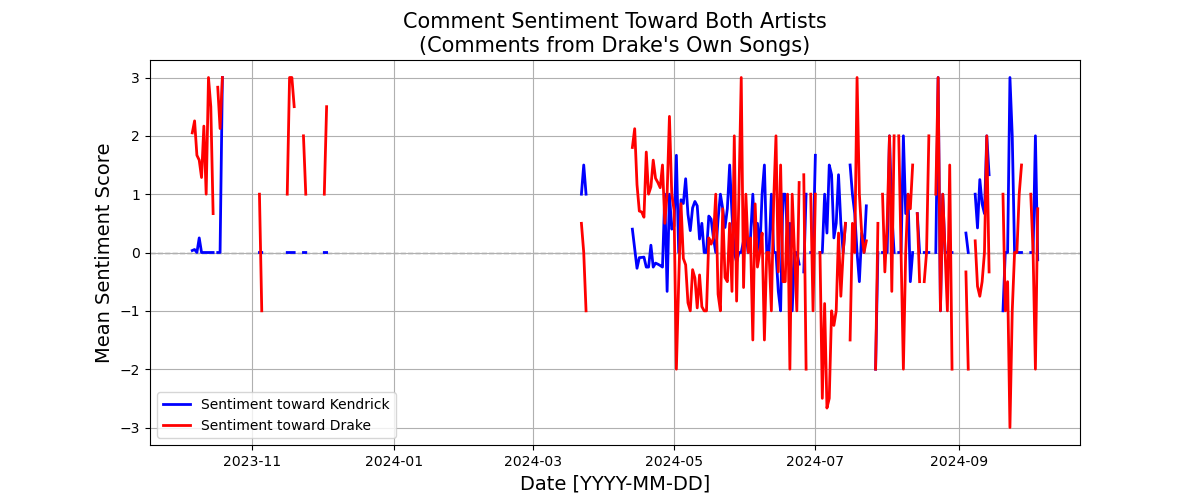

In [9]:
plt.close('all')
plt.figure(figsize=(12, 5))

drake_song_comments = comment_stats.loc[comment_stats['artist'].isin(['Drake', 'BagOnly_Drake', 'ScruFaceJean_Drake'])]

daily_kendrick = drake_song_comments.set_index('date').resample('D')['kendrick_score'].mean()
daily_drake = drake_song_comments.set_index('date').resample('D')['drake_score'].mean()

plt.plot(daily_kendrick.index, daily_kendrick.values, label='Sentiment toward Kendrick', color='blue', lw=2)
plt.plot(daily_drake.index, daily_drake.values, label='Sentiment toward Drake', color='red', lw=2)

plt.axhline(y=0, color='gray', lw=1, ls='--', zorder=0)

plt.title("Comment Sentiment Toward Both Artists\n(Comments from Drake's Own Songs)", fontsize=title_fontsize)
plt.xlabel("Date [YYYY-MM-DD]", fontsize=axis_label_fontsize)
plt.ylabel("Mean Sentiment Score", fontsize=axis_label_fontsize)
plt.rcParams['axes.labelsize'] = axes_fontsize
plt.legend(loc='best', fontsize=10)
plt.grid(True)
plt.show()

### plotting the comment sentiment for both artists from kendrick songs

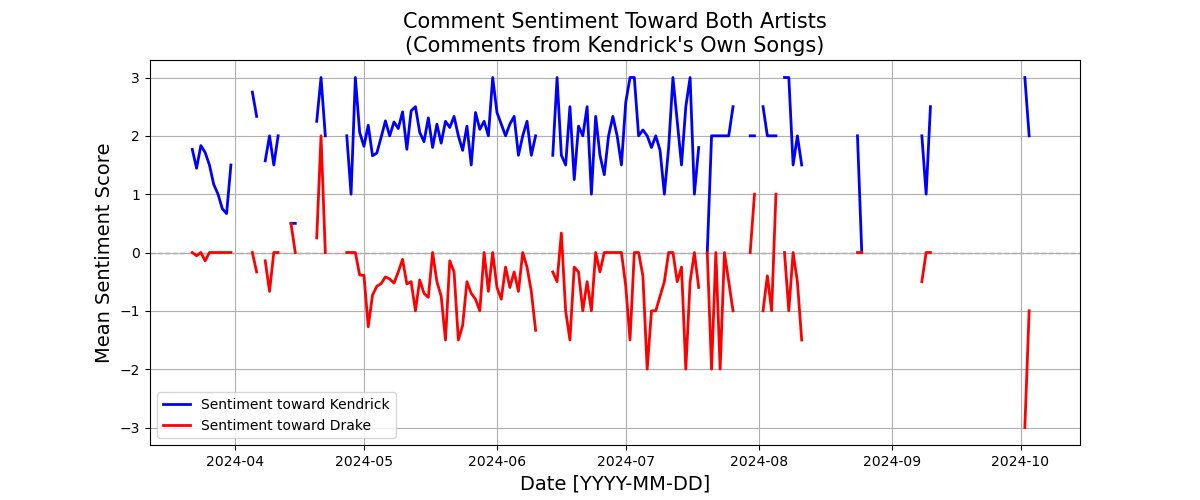

In [10]:
plt.close('all')
plt.figure(figsize=(12, 5))

kdot_song_comments = comment_stats.loc[comment_stats['artist'].isin(['Future', 'Kendrick_Lamar', 'RapNation_Kendrick_Lamar'])]

daily_kendrick = kdot_song_comments.set_index('date').resample('D')['kendrick_score'].mean()
daily_drake = kdot_song_comments.set_index('date').resample('D')['drake_score'].mean()

plt.plot(daily_kendrick.index, daily_kendrick.values, label='Sentiment toward Kendrick', color='blue', lw=2)
plt.plot(daily_drake.index, daily_drake.values, label='Sentiment toward Drake', color='red', lw=2)

plt.axhline(y=0, color='gray', lw=1, ls='--', zorder=0)

plt.title("Comment Sentiment Toward Both Artists\n(Comments from Kendrick's Own Songs)", fontsize=title_fontsize)
plt.xlabel("Date [YYYY-MM-DD]", fontsize=axis_label_fontsize)
plt.ylabel("Mean Sentiment Score", fontsize=axis_label_fontsize)
plt.rcParams['axes.labelsize'] = axes_fontsize
plt.legend(loc='best', fontsize=10)
plt.grid(True)
plt.show()

### plotting the comment sentiment for both artists over the entire beef aggregated from all artist released sources (not react or lyric channels)

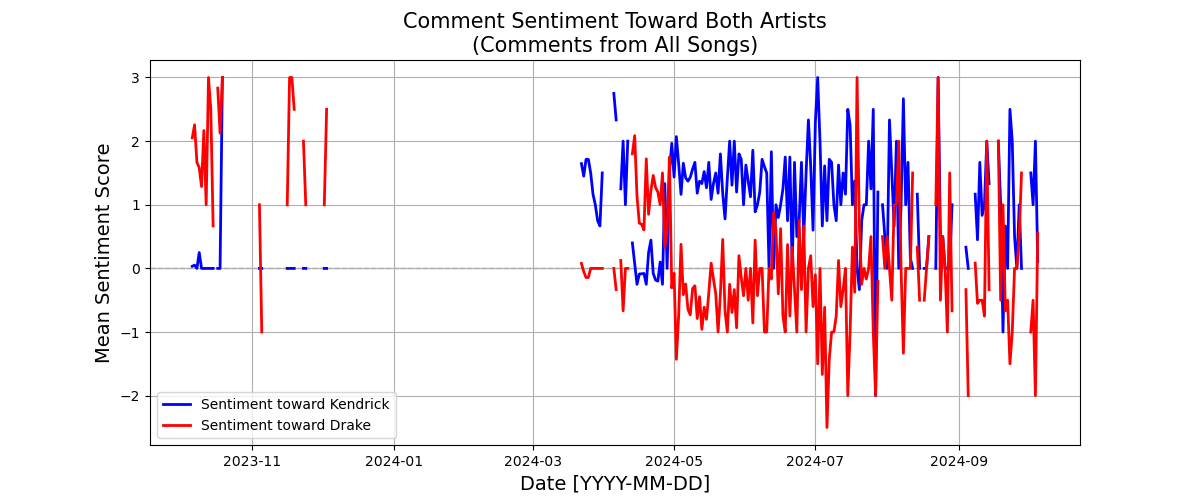

In [11]:
plt.close('all')
plt.figure(figsize=(12, 5))

daily_kendrick = comment_stats.set_index('date').resample('D')['kendrick_score'].mean()
daily_drake = comment_stats.set_index('date').resample('D')['drake_score'].mean()

plt.plot(daily_kendrick.index, daily_kendrick.values, label='Sentiment toward Kendrick', color='blue', lw=2)
plt.plot(daily_drake.index, daily_drake.values, label='Sentiment toward Drake', color='red', lw=2)

plt.axhline(y=0, color='gray', lw=1, ls='--', zorder=0)

plt.title("Comment Sentiment Toward Both Artists\n(Comments from All Songs)", fontsize=title_fontsize)
plt.xlabel("Date [YYYY-MM-DD]", fontsize=axis_label_fontsize)
plt.ylabel("Mean Sentiment Score", fontsize=axis_label_fontsize)
plt.rcParams['axes.labelsize'] = axes_fontsize
plt.legend(loc='best', fontsize=10)
plt.grid(True)
plt.show()